# OBELiX Benchmark Analysis

This notebook provides a comprehensive analysis of the OBELiX benchmark results, comparing traditional ML models (Random Forest, sklearn MLP), Tiny Recursive Models (TRM), and 3D structure-based models (CGCNN, M3GNet, SO3Net, SchNet, PaiNN) for predicting ionic conductivity in lithium solid-state electrolytes.

**Metrics:**
- **CV MAE** — Mean Absolute Error from 5-fold cross-validation (log₁₀ S cm⁻¹)
- **Test MAE** — MAE on the held-out test set
- **Test MAE (CIF)** — MAE on the CIF-only subset of the test set

**Data sources:**
- `benchmark/results_summary.csv` — per-model summary metrics
- `benchmark/results_folds.csv` — per-fold CV results
- `benchmark/results_training.csv` — per-epoch training curves
- `benchmark/optuna_all.csv` — Optuna hyperparameter search trials

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.facecolor": "white",
})

BENCH = "../benchmark"

summary = pd.read_csv(f"{BENCH}/results_summary.csv")
folds = pd.read_csv(f"{BENCH}/results_folds.csv")
training = pd.read_csv(f"{BENCH}/results_training.csv")
optuna = pd.read_csv(f"{BENCH}/optuna_all.csv")

# Create a display label combining model, features, and run
summary["label"] = summary.apply(
    lambda r: f"{r['model']} ({r['features']}, {r['run']})", axis=1
)

print(f"Summary:  {len(summary)} models")
print(f"Folds:    {len(folds)} rows")
print(f"Training: {len(training)} rows")
print(f"Optuna:   {len(optuna)} trials")

Summary:  12 models
Folds:    40 rows
Training: 607 rows
Optuna:   100 trials


## 1. Results Summary Table

All models ranked by cross-validation MAE (lower is better).

In [2]:
display_cols = ["label", "cv_mae", "cv_std", "test_mae", "test_mae_cif"]
summary_sorted = summary.sort_values("cv_mae")

styled = (
    summary_sorted[display_cols]
    .style
    .format({
        "cv_mae": "{:.3f}",
        "cv_std": "{:.3f}",
        "test_mae": "{:.3f}",
        "test_mae_cif": "{:.3f}",
    })
    .background_gradient(subset=["cv_mae", "test_mae"], cmap="RdYlGn_r")
    .set_caption("Benchmark Results (sorted by CV MAE)")
)
styled

,label,cv_mae,cv_std,test_mae,test_mae_cif
9,"TRM-Transformer (full, tuned)",0.925,0.160,1.384,1.655
1,"RF (full, tuned)",0.964,0.155,1.587,1.798
8,"TRM-Transformer (full, default_v2)",0.971,0.203,1.349,1.607
7,"TRM-Transformer (full, default_v1)",1.055,0.183,1.303,1.601
5,"TRM-MLP (full, tuned)",1.117,0.118,1.666,2.091
4,"TRM-MLP (full, default_v2)",1.142,0.117,1.544,1.901
6,"TRM-Transformer (cif, tuned)",1.144,0.308,1.519,nan
3,"TRM-MLP (full, default_v1)",1.161,0.095,1.570,1.927
0,"RF (cif, tuned)",1.248,0.130,1.667,1.949
11,"sklearn-MLP (full, tuned)",1.254,0.195,2.335,3.106


## 2. Model Comparison — CV MAE with Error Bars

Horizontal bar chart of cross-validation MAE for all model configurations, with ±1 standard deviation error bars. Models are sorted from best (top) to worst (bottom).

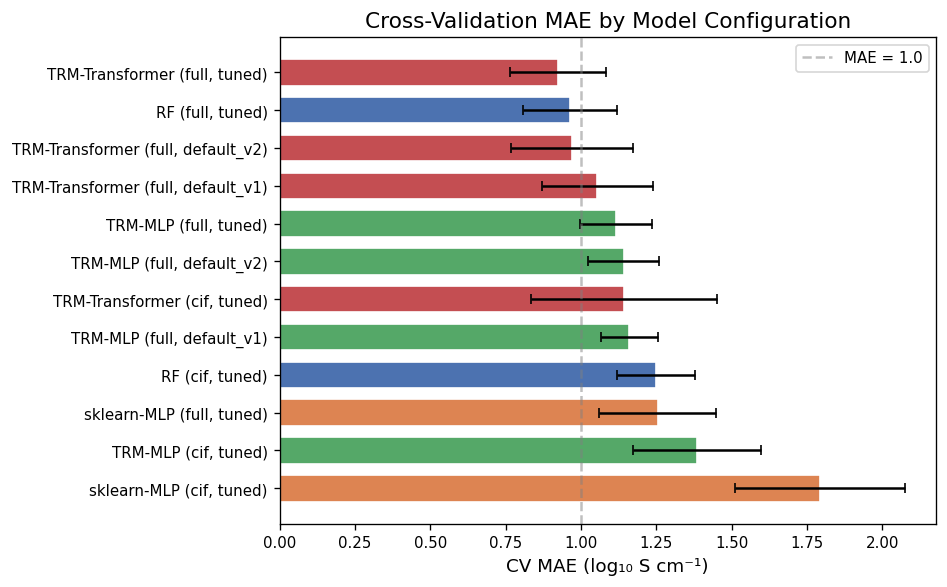

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

s = summary_sorted.iloc[::-1]  # reverse so best is on top
colors = []
palette = {"RF": "#4c72b0", "sklearn-MLP": "#dd8452", "TRM-MLP": "#55a868", "TRM-Transformer": "#c44e52"}
for m in s["model"]:
    colors.append(palette.get(m, "#8c8c8c"))

ax.barh(s["label"], s["cv_mae"], xerr=s["cv_std"], color=colors, edgecolor="white", height=0.7, capsize=3)
ax.set_xlabel("CV MAE (log₁₀ S cm⁻¹)")
ax.set_title("Cross-Validation MAE by Model Configuration")
ax.axvline(x=1.0, color="grey", linestyle="--", alpha=0.5, label="MAE = 1.0")
ax.legend()

plt.tight_layout()
plt.show()

## 3. CV MAE vs Test MAE — Generalization Gap

Scatter plot comparing cross-validation performance to held-out test performance. Points above the diagonal indicate models that generalize worse than their CV score suggests (overfitting to the CV splits).

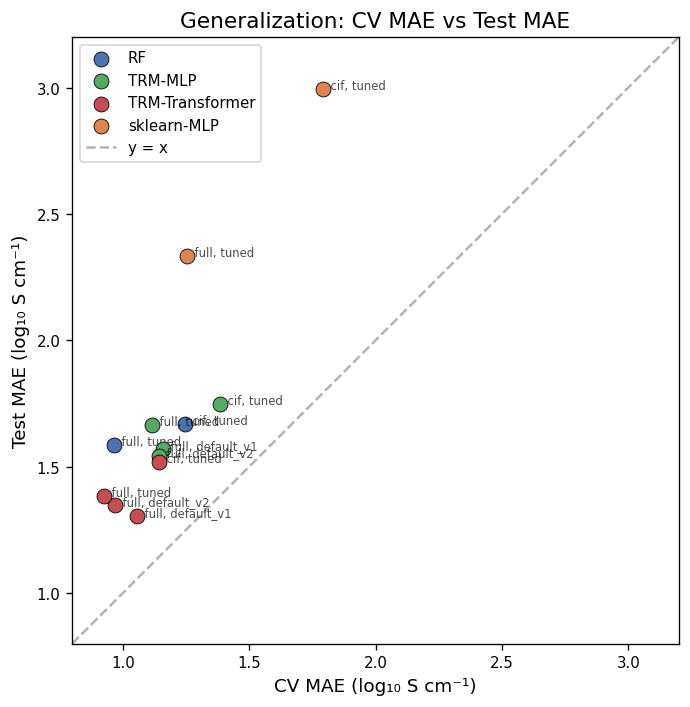

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))

for model, group in summary.groupby("model"):
    ax.scatter(group["cv_mae"], group["test_mae"], label=model,
               color=palette.get(model, "#8c8c8c"), s=80, edgecolors="black", linewidths=0.5, zorder=3)
    # Annotate with run type
    for _, row in group.iterrows():
        ax.annotate(f"  {row['features']}, {row['run']}", (row["cv_mae"], row["test_mae"]),
                     fontsize=7, alpha=0.7)

lims = [0.8, 3.2]
ax.plot(lims, lims, "k--", alpha=0.3, label="y = x")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("CV MAE (log₁₀ S cm⁻¹)")
ax.set_ylabel("Test MAE (log₁₀ S cm⁻¹)")
ax.set_title("Generalization: CV MAE vs Test MAE")
ax.legend(loc="upper left")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## 4. Test MAE Comparison — Full vs CIF-only

Side-by-side comparison of test set MAE on the full dataset versus the CIF-only subset. CIF-only entries have experimentally verified crystal structures, so performance on this subset reflects how well models handle structurally confirmed materials.

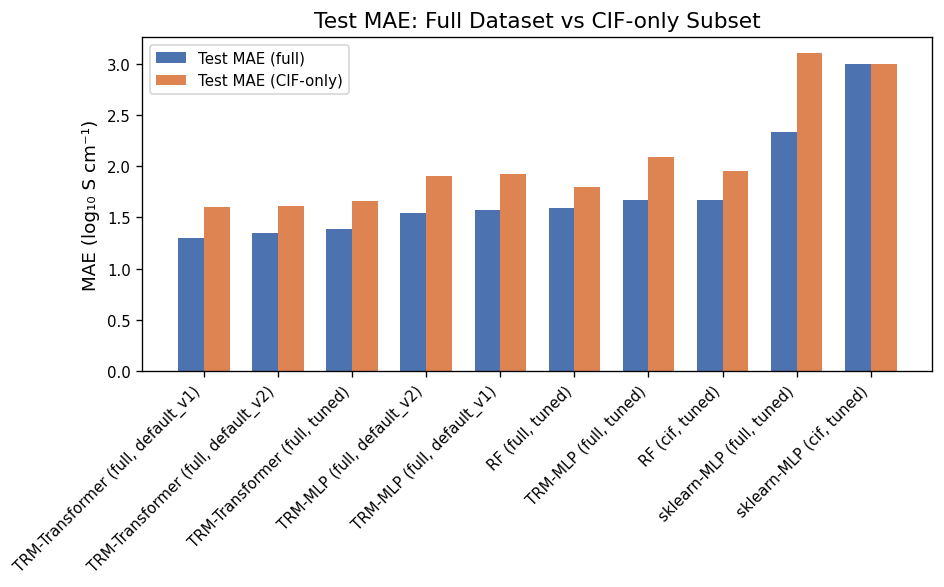

In [5]:
# Only models with both test_mae and test_mae_cif
has_both = summary.dropna(subset=["test_mae", "test_mae_cif"]).sort_values("test_mae")

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(has_both))
w = 0.35

ax.bar(x - w / 2, has_both["test_mae"], w, label="Test MAE (full)", color="#4c72b0")
ax.bar(x + w / 2, has_both["test_mae_cif"], w, label="Test MAE (CIF-only)", color="#dd8452")

ax.set_xticks(x)
ax.set_xticklabels(has_both["label"], rotation=45, ha="right")
ax.set_ylabel("MAE (log₁₀ S cm⁻¹)")
ax.set_title("Test MAE: Full Dataset vs CIF-only Subset")
ax.legend()

plt.tight_layout()
plt.show()

## 5. Per-Fold CV Analysis

Box/strip plots showing the distribution of validation MAE across the 5 CV folds. This reveals variance in model performance — a tight distribution means the model is consistent, while a wide spread may indicate sensitivity to the train/val split.

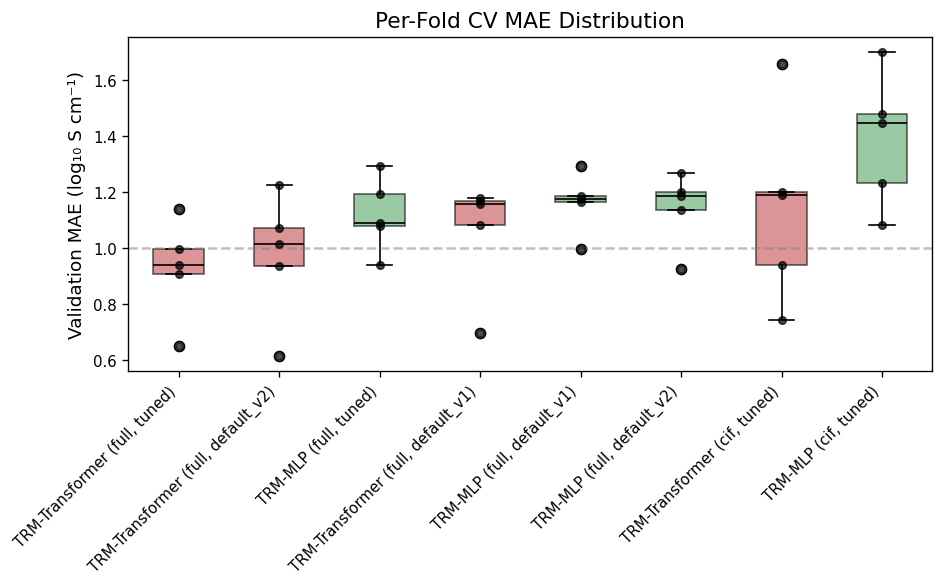

In [6]:
folds["label"] = folds.apply(
    lambda r: f"{r['model']} ({r['features']}, {r['run']})", axis=1
)

# Order by median val_mae
label_order = folds.groupby("label")["val_mae"].median().sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(8, 5))

positions = []
labels_used = []
for i, label in enumerate(label_order):
    subset = folds[folds["label"] == label]["val_mae"]
    bp = ax.boxplot(subset, positions=[i], widths=0.5, patch_artist=True,
                     boxprops=dict(facecolor=palette.get(label.split(" ")[0], "#8c8c8c"), alpha=0.6),
                     medianprops=dict(color="black"))
    # Overlay individual fold points
    ax.scatter([i] * len(subset), subset, color="black", s=20, zorder=5, alpha=0.7)
    labels_used.append(label)

ax.set_xticks(range(len(labels_used)))
ax.set_xticklabels(labels_used, rotation=45, ha="right")
ax.set_ylabel("Validation MAE (log₁₀ S cm⁻¹)")
ax.set_title("Per-Fold CV MAE Distribution")
ax.axhline(y=1.0, color="grey", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 6. Training Curves

Training and validation MAE over epochs for TRM models. These curves reveal learning dynamics — whether models converge, overfit, or benefit from longer training.

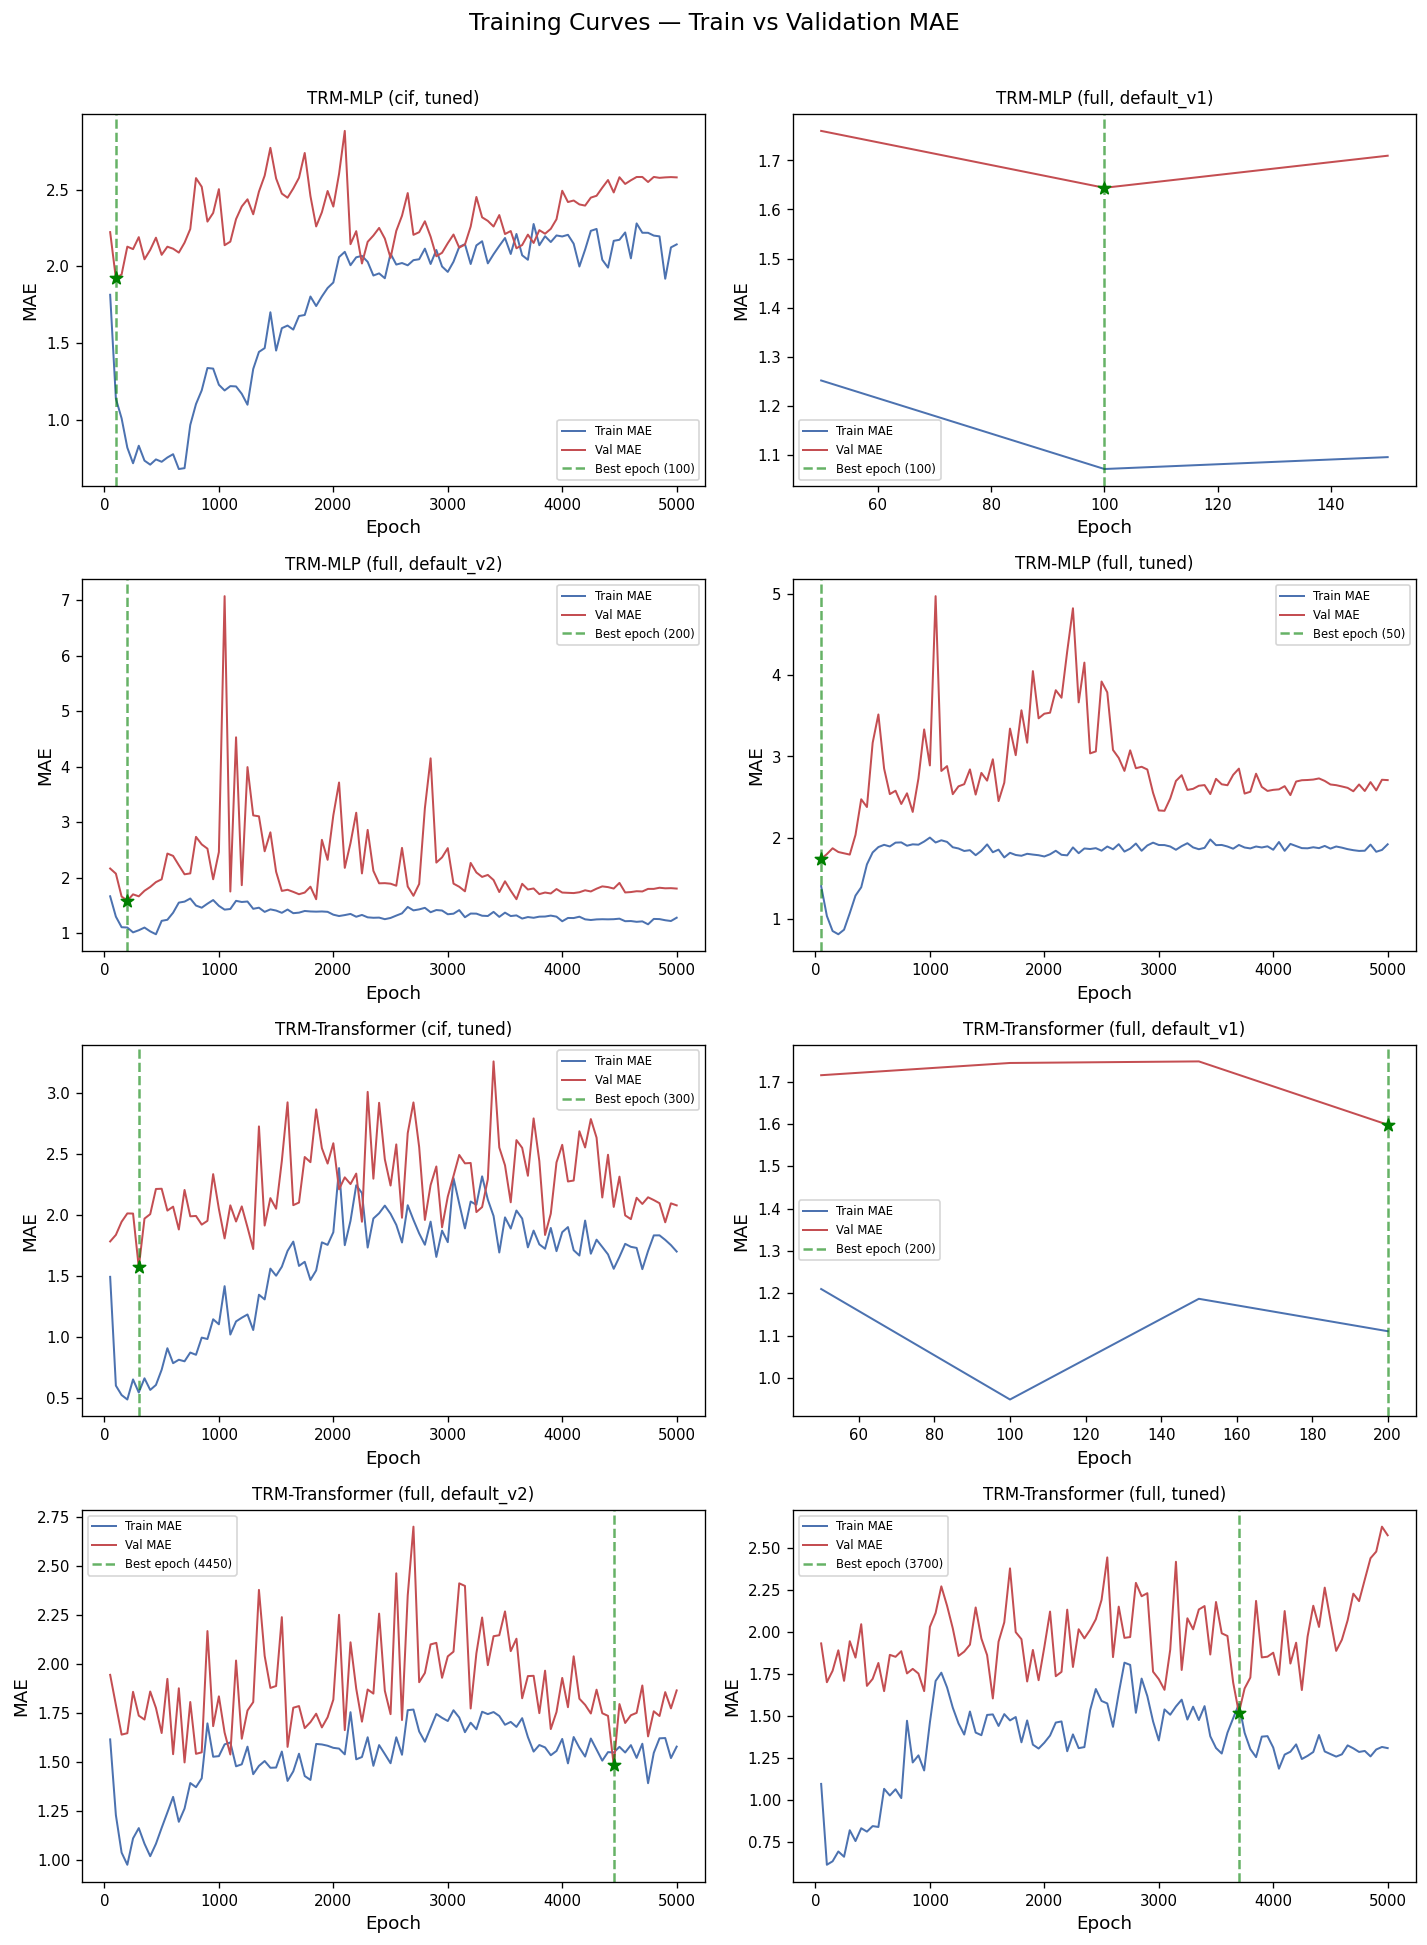

In [7]:
groups = training.groupby(["model", "features", "run"])

n_groups = len(groups)
ncols = 2
nrows = (n_groups + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows), sharex=False)
axes = axes.flatten()

for idx, ((model, features, run), grp) in enumerate(groups):
    ax = axes[idx]
    grp = grp.sort_values("epoch")
    ax.plot(grp["epoch"], grp["train_mae"], label="Train MAE", color="#4c72b0", linewidth=1.2)
    ax.plot(grp["epoch"], grp["val_mae"], label="Val MAE", color="#c44e52", linewidth=1.2)

    # Mark the actual best epoch (minimum val_mae), not the is_best_epoch flag
    # which only marks the final row of each run
    best_idx = grp["val_mae"].idxmin()
    best_epoch = grp.loc[best_idx, "epoch"]
    best_val = grp.loc[best_idx, "val_mae"]
    ax.axvline(best_epoch, color="green", linestyle="--", alpha=0.6, label=f"Best epoch ({best_epoch})")
    ax.scatter(best_epoch, best_val, color="green", s=60, zorder=5, marker="*")

    ax.set_title(f"{model} ({features}, {run})", fontsize=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MAE")
    ax.legend(fontsize=7)

# Hide unused axes
for idx in range(n_groups, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Training Curves — Train vs Validation MAE", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. Learning Rate Schedules

Visualize how the learning rate evolves over training for each TRM configuration.

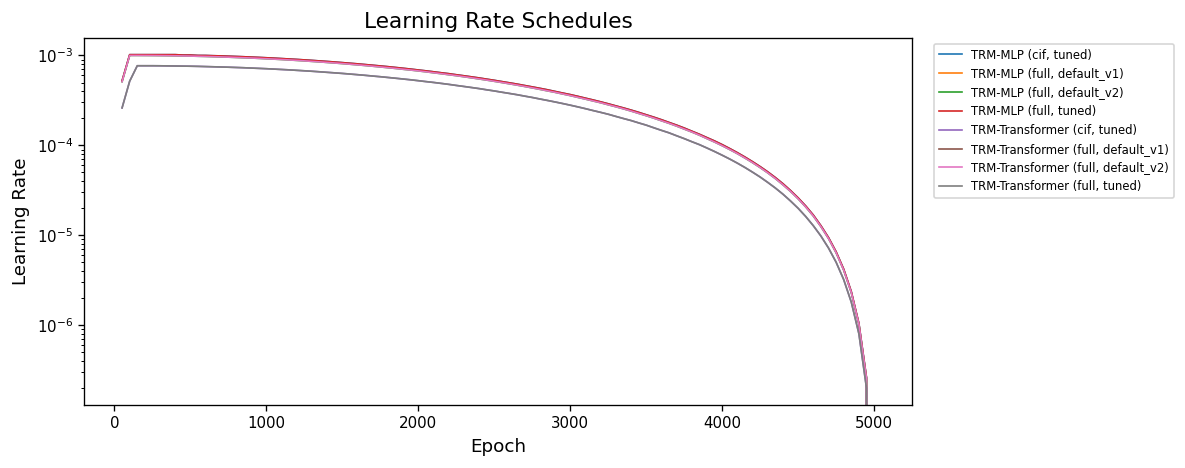

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))

for (model, features, run), grp in training.groupby(["model", "features", "run"]):
    grp = grp.sort_values("epoch")
    ax.plot(grp["epoch"], grp["lr"], label=f"{model} ({features}, {run})", linewidth=1)

ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_title("Learning Rate Schedules")
ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_yscale("log")

plt.tight_layout()
plt.show()

## 8. Optuna Hyperparameter Search

### 8a. Trial Convergence

How the best objective value (CV MAE) improves over successive Optuna trials. Flat regions indicate the search has found a strong optimum.

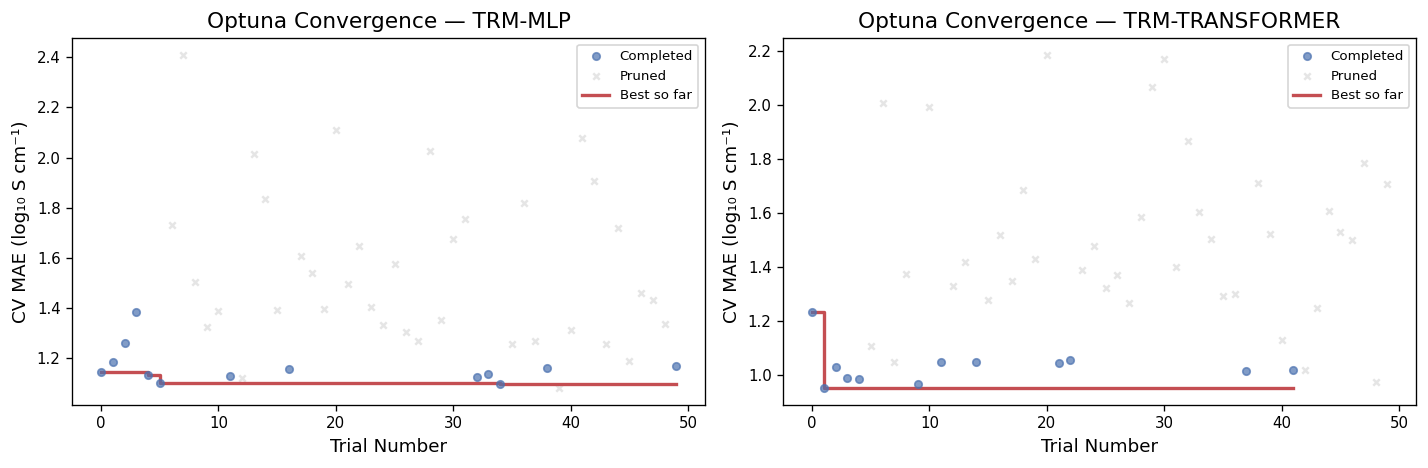

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, backbone in zip(axes, ["mlp", "transformer"]):
    trials = optuna[optuna["backbone"] == backbone].sort_values("number").copy()
    completed = trials[trials["state"] == "COMPLETE"]
    pruned = trials[trials["state"] == "PRUNED"]

    # All trials: scatter
    ax.scatter(completed["number"], completed["value"], color="#4c72b0", s=20, alpha=0.7, label="Completed", zorder=3)
    ax.scatter(pruned["number"], pruned["value"], color="#cccccc", s=15, alpha=0.5, label="Pruned", marker="x", zorder=2)

    # Best-so-far line
    best_so_far = completed["value"].cummin()
    ax.step(completed["number"], best_so_far, color="#c44e52", linewidth=2, where="post", label="Best so far")

    ax.set_xlabel("Trial Number")
    ax.set_ylabel("CV MAE (log₁₀ S cm⁻¹)")
    ax.set_title(f"Optuna Convergence — TRM-{backbone.upper()}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 8b. Hyperparameter Distributions

Distribution of key hyperparameters for completed trials, coloured by objective value. This shows which regions of hyperparameter space lead to good performance.

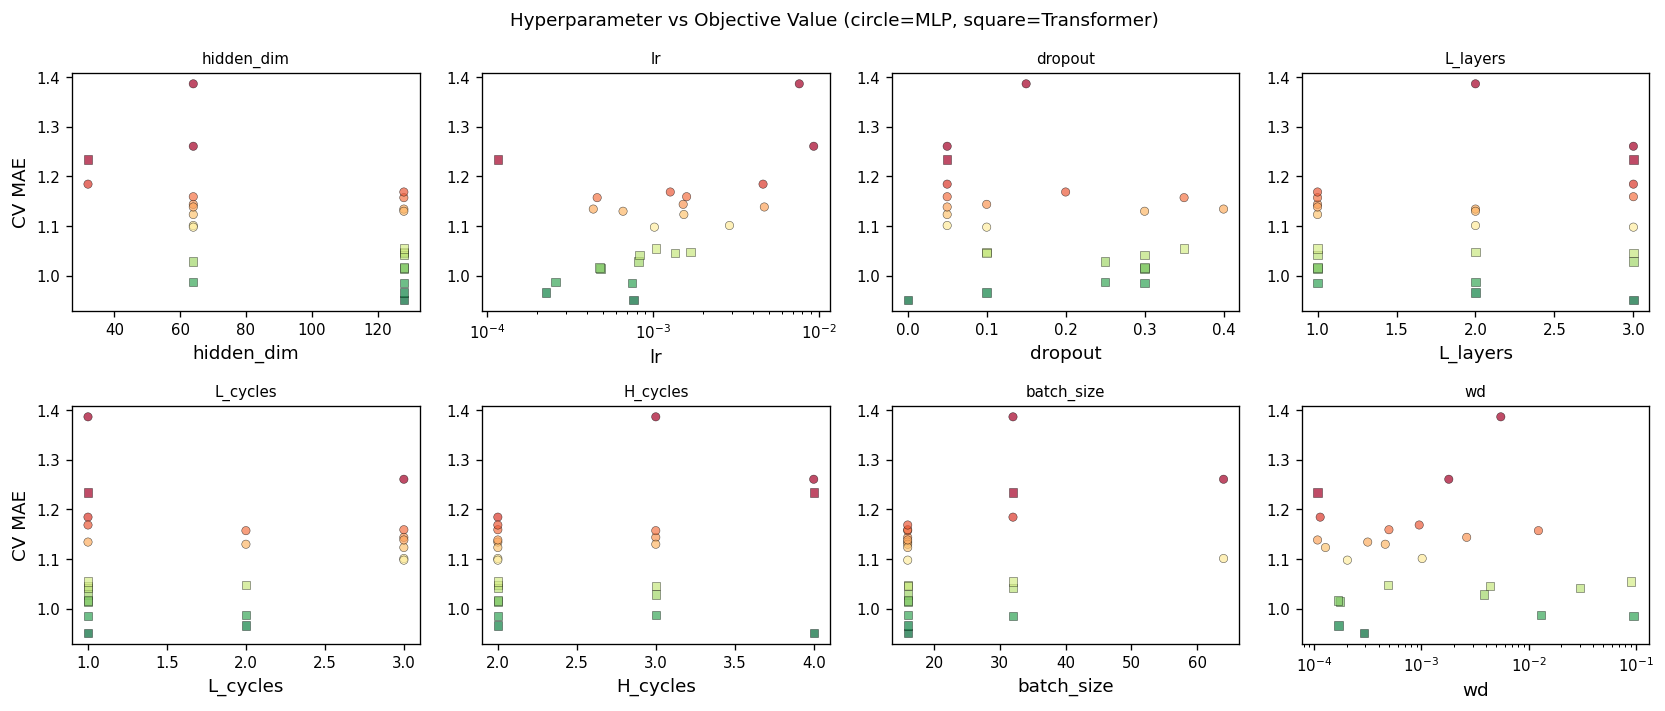

In [10]:
param_cols = [c for c in optuna.columns if c.startswith("params_")]
display_params = ["params_hidden_dim", "params_lr", "params_dropout", "params_L_layers",
                  "params_L_cycles", "params_H_cycles", "params_batch_size", "params_wd"]

completed = optuna[optuna["state"] == "COMPLETE"].copy()

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

for idx, param in enumerate(display_params):
    ax = axes[idx]
    for backbone, marker in [("mlp", "o"), ("transformer", "s")]:
        subset = completed[completed["backbone"] == backbone]
        sc = ax.scatter(subset[param], subset["value"], c=subset["value"],
                        cmap="RdYlGn_r", s=25, alpha=0.7, marker=marker,
                        edgecolors="black", linewidths=0.3, vmin=completed["value"].min(),
                        vmax=completed["value"].quantile(0.9))
    ax.set_xlabel(param.replace("params_", ""))
    ax.set_ylabel("CV MAE" if idx % 4 == 0 else "")
    ax.set_title(param.replace("params_", ""), fontsize=9)

    if param in ["params_lr", "params_wd"]:
        ax.set_xscale("log")

fig.suptitle("Hyperparameter vs Objective Value (circle=MLP, square=Transformer)", fontsize=11)
plt.tight_layout()
plt.show()

### 8c. Best Hyperparameters

The best trial for each backbone, showing the optimal configuration found by Optuna.

In [11]:
for backbone in ["mlp", "transformer"]:
    trials = completed[completed["backbone"] == backbone]
    best = trials.loc[trials["value"].idxmin()]
    print(f"=== Best TRM-{backbone.upper()} (CV MAE = {best['value']:.4f}) ===")
    for col in sorted(param_cols):
        print(f"  {col.replace('params_', ''):>12s}: {best[col]}")
    print()

=== Best TRM-MLP (CV MAE = 1.0979) ===
      H_cycles: 2
      L_cycles: 3
      L_layers: 3
    batch_size: 16
       dropout: 0.1
    hidden_dim: 64
            lr: 0.0010249743813789
     num_heads: 8
        warmup: 100
            wd: 0.0002036044537337

=== Best TRM-TRANSFORMER (CV MAE = 0.9511) ===
      H_cycles: 4
      L_cycles: 1
      L_layers: 3
    batch_size: 16
       dropout: 0.0
    hidden_dim: 128
            lr: 0.0007683818338208
     num_heads: 8
        warmup: 150
            wd: 0.000290705545565



### 8d. Trial Duration

Wall-clock time per Optuna trial, broken down by backbone and trial state. Pruned trials are much faster since they're terminated early.

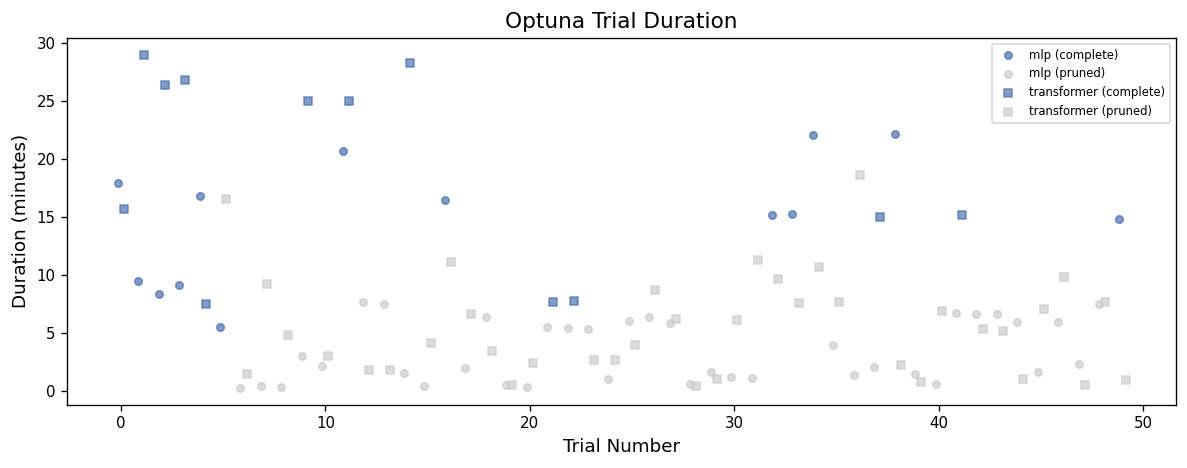

Duration statistics (minutes):
           mlp COMPLETE: n= 13, mean=14.9, median=15.3, max=22.2
           mlp   PRUNED: n= 37, mean=3.4, median=2.2, max=7.7
   transformer COMPLETE: n= 12, mean=19.1, median=20.4, max=29.0
   transformer   PRUNED: n= 38, mean=5.6, median=5.1, max=18.6


In [12]:
optuna["duration_sec"] = pd.to_timedelta(optuna["duration"]).dt.total_seconds()

fig, ax = plt.subplots(figsize=(10, 4))

for backbone, offset in [("mlp", -0.15), ("transformer", 0.15)]:
    for state, color in [("COMPLETE", "#4c72b0"), ("PRUNED", "#cccccc")]:
        subset = optuna[(optuna["backbone"] == backbone) & (optuna["state"] == state)]
        ax.scatter(subset["number"] + offset, subset["duration_sec"] / 60,
                   color=color, s=20, alpha=0.7,
                   marker="o" if backbone == "mlp" else "s",
                   label=f"{backbone} ({state.lower()})")

ax.set_xlabel("Trial Number")
ax.set_ylabel("Duration (minutes)")
ax.set_title("Optuna Trial Duration")
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

# Summary statistics
print("Duration statistics (minutes):")
for backbone in ["mlp", "transformer"]:
    for state in ["COMPLETE", "PRUNED"]:
        subset = optuna[(optuna["backbone"] == backbone) & (optuna["state"] == state)]
        if len(subset) > 0:
            mins = subset["duration_sec"] / 60
            print(f"  {backbone:>12s} {state:>8s}: n={len(subset):>3d}, "
                  f"mean={mins.mean():.1f}, median={mins.median():.1f}, max={mins.max():.1f}")

## 9. Feature Set Impact — Full vs CIF-only

Comparing the effect of using the full feature set (composition + computed lattice parameters) versus the CIF-only subset (experimentally verified structures only) across model types.

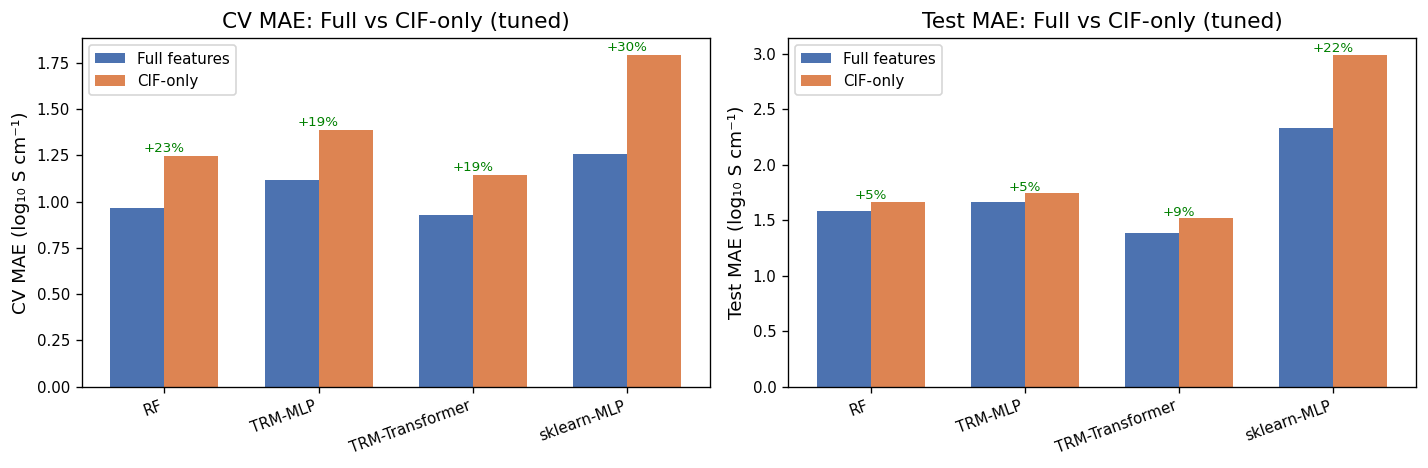

In [13]:
# Compare tuned models across feature sets
tuned = summary[summary["run"] == "tuned"].copy()
models_with_both = tuned.groupby("model").filter(lambda g: set(g["features"]) == {"full", "cif"})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, title in zip(axes, ["cv_mae", "test_mae"], ["CV MAE", "Test MAE"]):
    models = models_with_both["model"].unique()
    x = np.arange(len(models))
    w = 0.35

    full_vals = [models_with_both[(models_with_both["model"] == m) & (models_with_both["features"] == "full")][metric].values[0] for m in models]
    cif_vals = [models_with_both[(models_with_both["model"] == m) & (models_with_both["features"] == "cif")][metric].values[0] for m in models]

    bars1 = ax.bar(x - w / 2, full_vals, w, label="Full features", color="#4c72b0")
    bars2 = ax.bar(x + w / 2, cif_vals, w, label="CIF-only", color="#dd8452")

    # Annotate improvement
    for i, (f, c) in enumerate(zip(full_vals, cif_vals)):
        pct = (c - f) / c * 100
        ax.annotate(f"{pct:+.0f}%", (i, max(f, c) + 0.02), ha="center", fontsize=8, color="green" if pct > 0 else "red")

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=20, ha="right")
    ax.set_ylabel(f"{title} (log₁₀ S cm⁻¹)")
    ax.set_title(f"{title}: Full vs CIF-only (tuned)")
    ax.legend()

plt.tight_layout()
plt.show()

## 10. Tuned vs Default Configurations (TRM)

The TRM models were run with both default hyperparameters (v1 and v2) and Optuna-tuned hyperparameters. This comparison shows how much hyperparameter tuning helps.

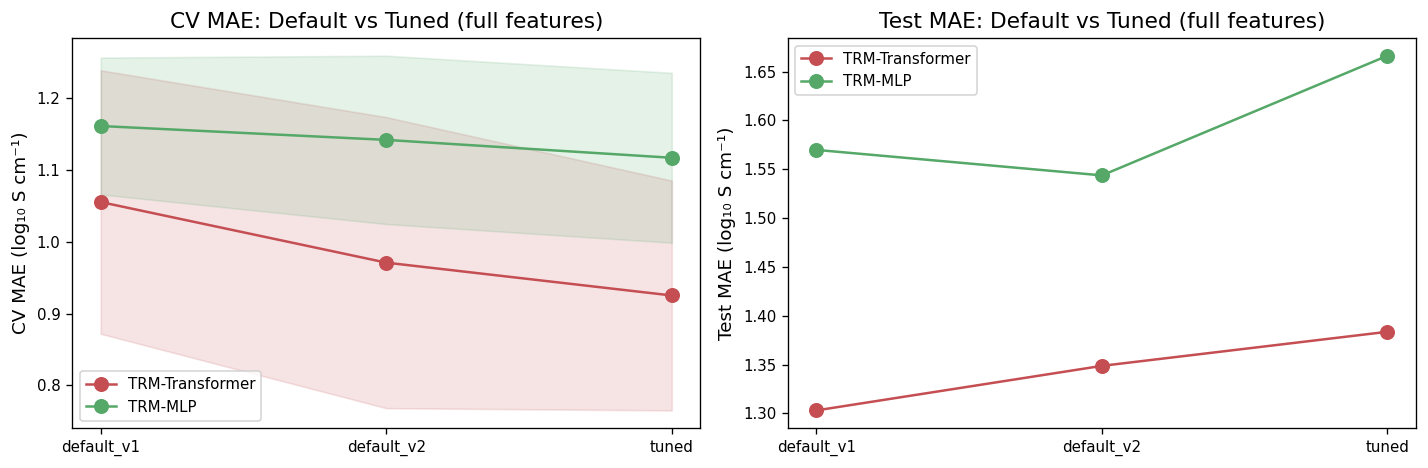

In [14]:
trm_full = summary[(summary["model"].str.startswith("TRM")) & (summary["features"] == "full")].copy()
trm_full = trm_full.sort_values(["model", "run"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, title in zip(axes, ["cv_mae", "test_mae"], ["CV MAE", "Test MAE"]):
    for model, color in [("TRM-Transformer", "#c44e52"), ("TRM-MLP", "#55a868")]:
        subset = trm_full[trm_full["model"] == model]
        ax.plot(subset["run"], subset[metric], "o-", color=color, label=model, markersize=8)
        if metric == "cv_mae":
            ax.fill_between(subset["run"],
                            subset["cv_mae"] - subset["cv_std"],
                            subset["cv_mae"] + subset["cv_std"],
                            alpha=0.15, color=color)

    ax.set_ylabel(f"{title} (log₁₀ S cm⁻¹)")
    ax.set_title(f"{title}: Default vs Tuned (full features)")
    ax.legend()

plt.tight_layout()
plt.show()

## 11. Hyperparameter Importance

Correlation of each hyperparameter with the objective value (CV MAE) for completed Optuna trials, split by backbone. Positive correlation means higher values of the parameter lead to worse performance; negative means they help.

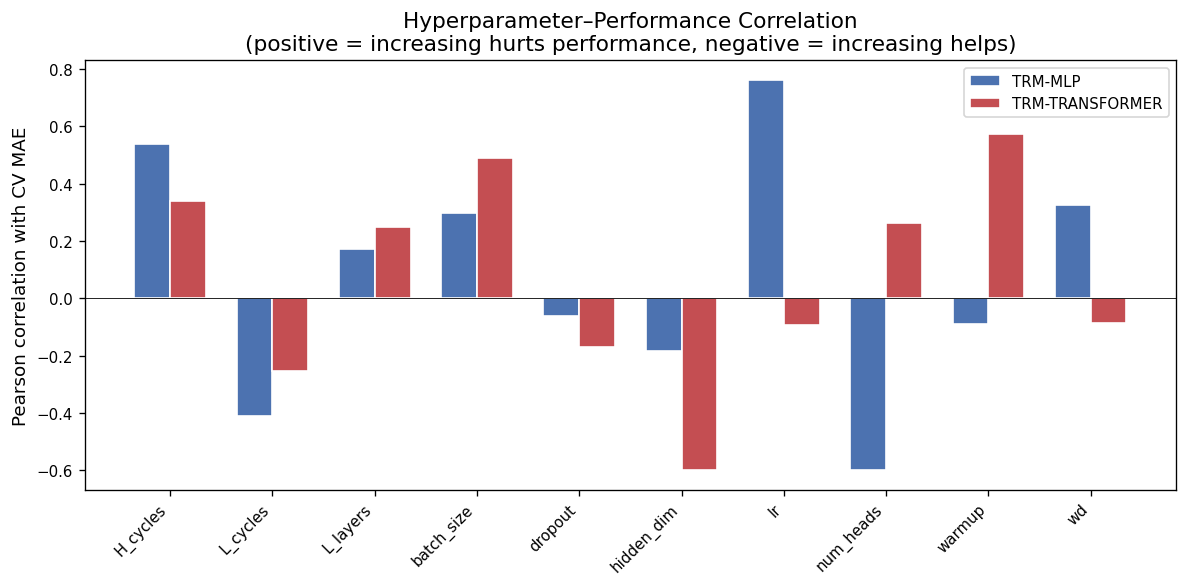

In [15]:
param_names = [c.replace("params_", "") for c in param_cols]

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(param_names))
w = 0.35

for i, (backbone, color) in enumerate([("mlp", "#4c72b0"), ("transformer", "#c44e52")]):
    subset = completed[completed["backbone"] == backbone]
    corrs = [subset[col].corr(subset["value"]) for col in param_cols]
    ax.bar(x + (i - 0.5) * w, corrs, w, label=f"TRM-{backbone.upper()}", color=color, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(param_names, rotation=45, ha="right")
ax.set_ylabel("Pearson correlation with CV MAE")
ax.set_title("Hyperparameter–Performance Correlation\n(positive = increasing hurts performance, negative = increasing helps)")
ax.axhline(0, color="black", linewidth=0.5)
ax.legend()

plt.tight_layout()
plt.show()

## 12. Key Findings

Summary statistics and takeaways from the benchmark analysis.

In [16]:
# Best model by CV MAE
best_cv = summary.loc[summary["cv_mae"].idxmin()]
print(f"Best CV MAE:    {best_cv['label']}  —  {best_cv['cv_mae']:.3f} ± {best_cv['cv_std']:.3f}")

# Best model by Test MAE
best_test = summary.loc[summary["test_mae"].idxmin()]
print(f"Best Test MAE:  {best_test['label']}  —  {best_test['test_mae']:.3f}")

# Best model by Test MAE (CIF-only)
cif_subset = summary.dropna(subset=["test_mae_cif"])
best_cif = cif_subset.loc[cif_subset["test_mae_cif"].idxmin()]
print(f"Best CIF MAE:   {best_cif['label']}  —  {best_cif['test_mae_cif']:.3f}")

print("\n--- Generalization Gap (test_mae - cv_mae) ---")
summary_sorted_gap = summary.copy()
summary_sorted_gap["gap"] = summary_sorted_gap["test_mae"] - summary_sorted_gap["cv_mae"]
for _, row in summary_sorted_gap.sort_values("gap").iterrows():
    print(f"  {row['label']:>45s}: {row['gap']:+.3f}")

print(f"\n--- Feature Set Effect (tuned models, full vs cif) ---")
for model in ["RF", "sklearn-MLP", "TRM-MLP", "TRM-Transformer"]:
    full = summary[(summary["model"] == model) & (summary["features"] == "full") & (summary["run"] == "tuned")]
    cif = summary[(summary["model"] == model) & (summary["features"] == "cif") & (summary["run"] == "tuned")]
    if len(full) > 0 and len(cif) > 0:
        diff = cif["cv_mae"].values[0] - full["cv_mae"].values[0]
        print(f"  {model:>20s}: full={full['cv_mae'].values[0]:.3f}, cif={cif['cv_mae'].values[0]:.3f}, diff={diff:+.3f}")

Best CV MAE:    TRM-Transformer (full, tuned)  —  0.925 ± 0.160
Best Test MAE:  TRM-Transformer (full, default_v1)  —  1.303
Best CIF MAE:   TRM-Transformer (full, default_v1)  —  1.601

--- Generalization Gap (test_mae - cv_mae) ---
             TRM-Transformer (full, default_v1): +0.248
                           TRM-MLP (cif, tuned): +0.360
                   TRM-Transformer (cif, tuned): +0.375
             TRM-Transformer (full, default_v2): +0.378
                     TRM-MLP (full, default_v2): +0.402
                     TRM-MLP (full, default_v1): +0.409
                                RF (cif, tuned): +0.419
                  TRM-Transformer (full, tuned): +0.458
                          TRM-MLP (full, tuned): +0.549
                               RF (full, tuned): +0.623
                      sklearn-MLP (full, tuned): +1.080
                       sklearn-MLP (cif, tuned): +1.199

--- Feature Set Effect (tuned models, full vs cif) ---
                    RF: full=0.964, ci